#  Electricity Load Forecasting: LSTM vs 1D CNN
### Deep Learning Time Series Project | UCI Electricity Load Diagrams Dataset

---

| Item | Detail |
|------|--------|
| **Dataset** | UCI Electricity Load Diagrams (2011–2014) |
| **Task** | Time Series Forecasting |
| **Models** | LSTM · 1D CNN |
| **Framework** | TensorFlow / Keras |
| **Language** | Python 3.9+ |

---

##  Project Structure
```
electricity_forecast/
│
├── data/
│   └── LD2011_2014.txt          # Raw dataset
│
├── models/
│   ├── lstm_model.h5            # Saved LSTM model
│   └── cnn_model.h5             # Saved CNN model
│
├── notebooks/
│   └── electricity_forecasting.ipynb
│
└── outputs/
    └── plots/                   # Saved visualizations
```

##  Notebook Sections
1. Project Setup & Imports
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Create Sequences (Sliding Window)
6. Build LSTM Model
7. Train LSTM Model
8. Build 1D CNN Model
9. Train CNN Model
10. Model Evaluation
11. Model Comparison
12. Challenges & Solutions
13. Final Conclusion

---
##  STEP 1 — Project Setup
### Install & Import All Required Libraries

In [1]:
# ── Core Libraries ────────────────────────────────────────────────────────────
import os
import time
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Conv1D, MaxPooling1D, Dense,
    Dropout, Flatten, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Config ────────────────────────────────────────────────────────────────────
WINDOW_SIZE   = 24      # Look-back: 24 time steps (e.g. 24 hours)
BATCH_SIZE    = 64
EPOCHS        = 50
TEST_RATIO    = 0.2
CLIENT        = 'MT_001'  # Single client to forecast

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models',  exist_ok=True)
os.makedirs('../data',    exist_ok=True) # Added: Create the data directory

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'Pandas version     : {pd.__version__}')
print('\n All libraries loaded successfully!')

TensorFlow version : 2.19.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2

 All libraries loaded successfully!


---
## 🟩 STEP 2 — Load Dataset

> **Dataset:** UCI Electricity Load Diagrams 2011–2014  
> **URL:** https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014  
> **Format:** `;` delimited `.txt` file, 15-minute intervals, 370 clients



In [2]:
!wget https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip -O LD2011_2014.zip
!unzip LD2011_2014.zip -d ./data/

--2026-04-09 00:18:31--  https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘LD2011_2014.zip’

LD2011_2014.zip         [       <=>          ] 249.23M  33.0MB/s    in 5.3s    

2026-04-09 00:18:36 (47.2 MB/s) - ‘LD2011_2014.zip’ saved [261335609]

Archive:  LD2011_2014.zip
  inflating: ./data/LD2011_2014.txt  
   creating: ./data/__MACOSX/
  inflating: ./data/__MACOSX/._LD2011_2014.txt  


In [3]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
DATA_PATH = '/content/data/LD2011_2014.txt'

# The file uses ';' as delimiter and ',' as decimal separator
df_raw = pd.read_csv(
    DATA_PATH,
    sep=';',           # Semicolon-delimited
    decimal=',',       # European decimal format
    index_col=0,       # First column is the datetime index
    parse_dates=True,  # Auto-parse index as datetime
    low_memory=False
)

# ── Ensure DatetimeIndex ──────────────────────────────────────────────────────
df_raw.index = pd.to_datetime(df_raw.index)
df_raw.index.name = 'datetime'

# ── Sort chronologically ──────────────────────────────────────────────────────
df_raw = df_raw.sort_index()

# ── Inspect ───────────────────────────────────────────────────────────────────
print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Shape            : {df_raw.shape}  (rows × clients)')
print(f'Date range       : {df_raw.index[0]}  →  {df_raw.index[-1]}')
print(f'Frequency        : {pd.infer_freq(df_raw.index[:100])}')
print(f'Number of clients: {df_raw.shape[1]}')
print(f'Memory usage     : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('First 3 rows:')
display(df_raw.head(3))
print()
print('Data types:')
print(df_raw.dtypes.value_counts())
print()
print('Basic statistics (first 5 clients):')
display(df_raw.iloc[:, :5].describe().round(4))

print('\n Dataset loaded successfully!')

DATASET OVERVIEW
Shape            : (140256, 370)  (rows × clients)
Date range       : 2011-01-01 00:15:00  →  2015-01-01 00:00:00
Frequency        : 15min
Number of clients: 370
Memory usage     : 416.3 MB

First 3 rows:


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Data types:
float64    370
Name: count, dtype: int64

Basic statistics (first 5 clients):


,MT_001,MT_002,MT_003,MT_004,MT_005
count,140256.0000,140256.0000,140256.0000,140256.0000,140256.0000
mean,3.9708,20.7685,2.9183,82.1845,37.2403
std,5.9840,13.2724,11.0145,58.2484,26.4613
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,2.8450,0.0000,36.5854,15.8537
50%,1.2690,24.8933,1.7376,87.3984,39.0244
75%,2.5381,29.8720,1.7376,115.8537,54.8780
max,48.2234,115.2205,151.1729,321.1382,150.0000



 Dataset loaded successfully!


In [4]:
import os

# List the contents of the data directory
print(os.listdir('../data/'))

# Optionally, check if the specific file exists
file_exists = os.path.exists('../data/LD2011_2014.txt')
print(f"File 'LD2011_2014.txt' exists: {file_exists}")

[]
File 'LD2011_2014.txt' exists: False


---
## 🟩 STEP 3 — Exploratory Data Analysis (EDA)

In [5]:
# ── 3.1 Missing Values Analysis ───────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100

print('=' * 50)
print('MISSING VALUES REPORT')
print('=' * 50)
print(f'Clients with NO missing values : {(missing == 0).sum()}')
print(f'Clients WITH missing values    : {(missing > 0).sum()}')
print(f'Total missing cells            : {missing.sum():,}')
print(f'Missing %% (overall)            : {missing_pct.mean():.2f}%%')

MISSING VALUES REPORT
Clients with NO missing values : 370
Clients WITH missing values    : 0
Total missing cells            : 0
Missing %% (overall)            : 0.00%%


In [6]:
# ── 3.2 Select a single client & resample to hourly ───────────────────────────
# Dataset is 15-min; resample to hourly for cleaner analysis
series = df_raw[CLIENT].resample('H').mean()
series = series.dropna()

print(f'Client      : {CLIENT}')
print(f'Hourly obs  : {len(series):,}')
print(f'Date range  : {series.index[0]}  →  {series.index[-1]}')
print(f'Mean load   : {series.mean():.4f} kW')
print(f'Std dev     : {series.std():.4f} kW')
print(f'Min / Max   : {series.min():.4f}  /  {series.max():.4f} kW')

Client      : MT_001
Hourly obs  : 35,065
Date range  : 2011-01-01 00:00:00  →  2015-01-01 00:00:00
Mean load   : 3.9707 kW
Std dev     : 5.7145 kW
Min / Max   : 0.0000  /  34.5812 kW


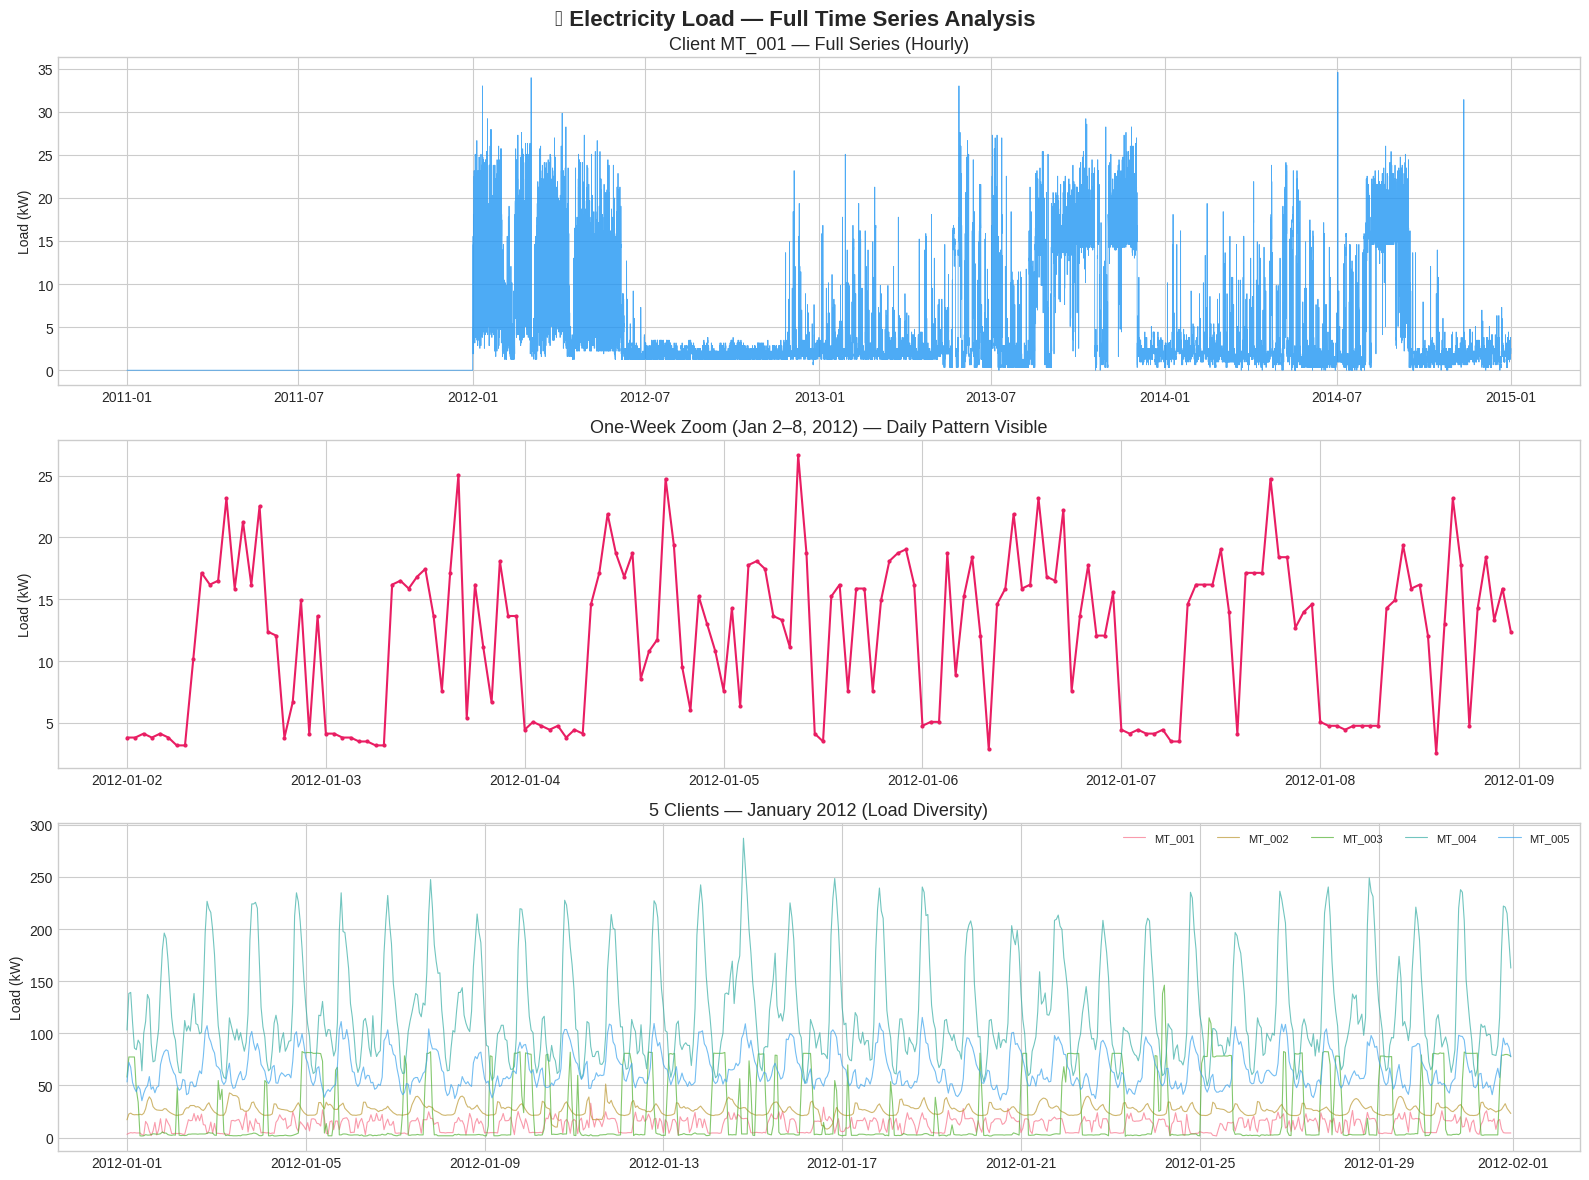

 Plot saved.


In [7]:
# ── 3.3 Full time series plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('⚡ Electricity Load — Full Time Series Analysis', fontsize=16, fontweight='bold')

# Full series
axes[0].plot(series, color='#2196F3', linewidth=0.6, alpha=0.8)
axes[0].set_title(f'Client {CLIENT} — Full Series (Hourly)', fontsize=13)
axes[0].set_ylabel('Load (kW)')
axes[0].set_xlabel('')

# One week zoom
week_data = series['2012-01-02':'2012-01-08']
axes[1].plot(week_data, color='#E91E63', linewidth=1.5, marker='o', markersize=2)
axes[1].set_title('One-Week Zoom (Jan 2–8, 2012) — Daily Pattern Visible', fontsize=13)
axes[1].set_ylabel('Load (kW)')

# Multiple clients
clients_sample = df_raw.columns[:5]
one_month = df_raw.loc['2012-01-01':'2012-01-31', clients_sample].resample('H').mean()
for col in clients_sample:
    axes[2].plot(one_month[col], linewidth=0.8, alpha=0.7, label=col)
axes[2].set_title('5 Clients — January 2012 (Load Diversity)', fontsize=13)
axes[2].set_ylabel('Load (kW)')
axes[2].legend(fontsize=8, ncol=5)

plt.tight_layout()
plt.savefig('../outputs/01_time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot saved.')

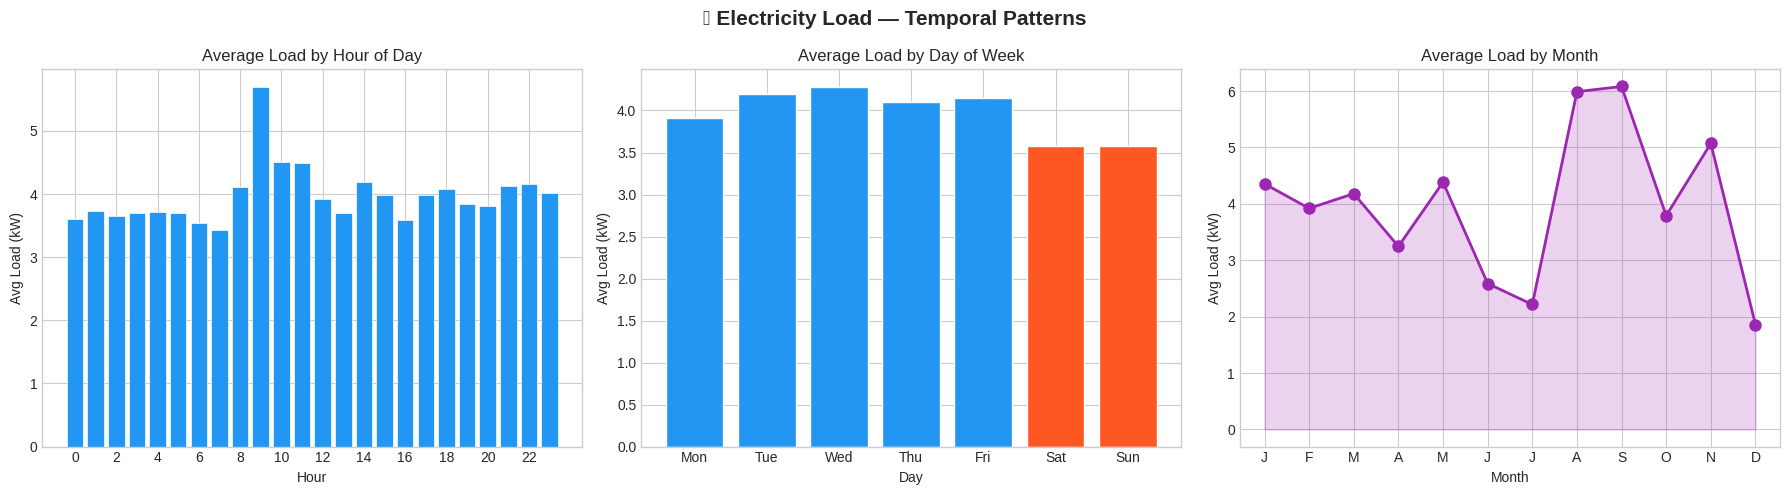

 Key findings:
  Peak hour     : 9:00  (load = 5.6902 kW)
  Lowest hour   : 7:00  (load = 3.4353 kW)
  Peak day      : Wednesday
  Lowest day    : Sunday
  Peak month    : 9


In [8]:
# ── 3.4 Daily & Weekly Pattern Analysis ──────────────────────────────────────
df_patterns = series.to_frame(name='load')
df_patterns['hour']    = df_patterns.index.hour
df_patterns['weekday'] = df_patterns.index.day_name()
df_patterns['month']   = df_patterns.index.month
df_patterns['year']    = df_patterns.index.year

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('⚡ Electricity Load — Temporal Patterns', fontsize=15, fontweight='bold')

# Hourly pattern
hourly_avg = df_patterns.groupby('hour')['load'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='#2196F3', edgecolor='white', linewidth=0.5)
axes[0].set_title('Average Load by Hour of Day', fontsize=12)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Load (kW)')
axes[0].set_xticks(range(0, 24, 2))

# Weekly pattern
weekly_avg = df_patterns.groupby('weekday')['load'].mean().reindex(weekday_order)
colors = ['#2196F3']*5 + ['#FF5722']*2   # Weekdays blue, weekends orange
axes[1].bar(range(7), weekly_avg.values, color=colors, edgecolor='white')
axes[1].set_title('Average Load by Day of Week', fontsize=12)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Load (kW)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

# Monthly pattern
monthly_avg = df_patterns.groupby('month')['load'].mean()
axes[2].plot(monthly_avg.index, monthly_avg.values, 'o-', color='#9C27B0', linewidth=2, markersize=8)
axes[2].fill_between(monthly_avg.index, monthly_avg.values, alpha=0.2, color='#9C27B0')
axes[2].set_title('Average Load by Month', fontsize=12)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Avg Load (kW)')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

plt.tight_layout()
plt.savefig('../outputs/02_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Key findings:')
print(f'  Peak hour     : {hourly_avg.idxmax()}:00  (load = {hourly_avg.max():.4f} kW)')
print(f'  Lowest hour   : {hourly_avg.idxmin()}:00  (load = {hourly_avg.min():.4f} kW)')
print(f'  Peak day      : {weekly_avg.idxmax()}')
print(f'  Lowest day    : {weekly_avg.idxmin()}')
print(f'  Peak month    : {monthly_avg.idxmax()}')

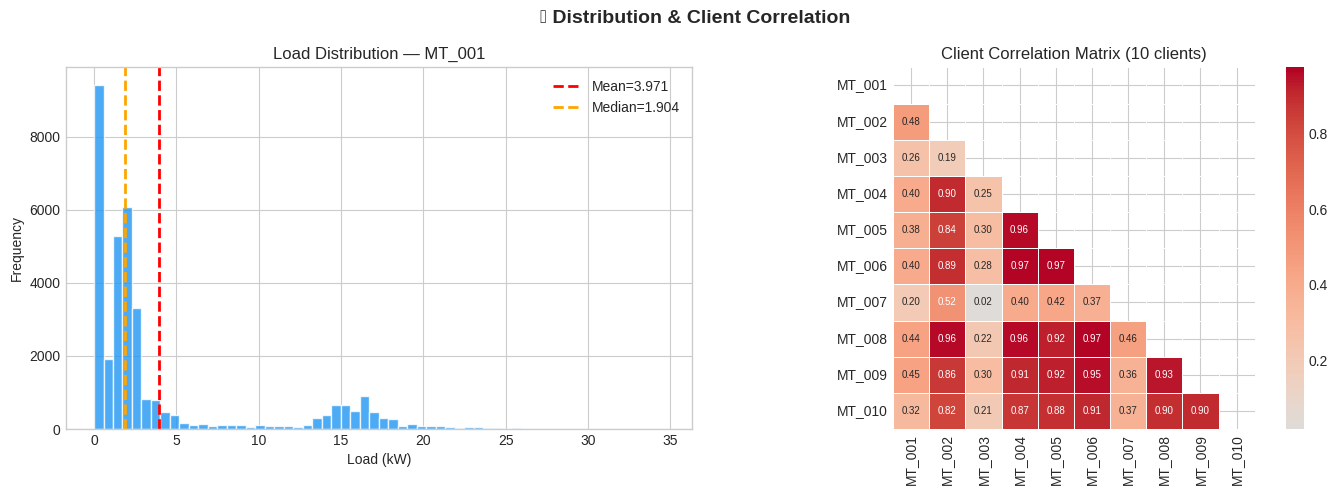

In [9]:
# ── 3.5 Distribution & Correlation Heatmap ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('⚡ Distribution & Client Correlation', fontsize=14, fontweight='bold')

# Load distribution
axes[0].hist(series.values, bins=60, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(series.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={series.mean():.3f}')
axes[0].axvline(series.median(), color='orange', linestyle='--', linewidth=2, label=f'Median={series.median():.3f}')
axes[0].set_title(f'Load Distribution — {CLIENT}', fontsize=12)
axes[0].set_xlabel('Load (kW)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Correlation heatmap (first 10 clients)
corr = df_raw.iloc[:, :10].resample('D').mean().corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            annot_kws={'size': 7})
axes[1].set_title('Client Correlation Matrix (10 clients)', fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/03_distribution_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🟩 STEP 4 — Data Preprocessing

### Why each step is necessary:

| Step | Reason |
|------|--------|
| **Handle missing values** | NaN values break gradient calculations in neural networks |
| **Normalization** | LSTM/CNN use sigmoid/tanh activations that saturate outside [0,1]; equal gradient scale prevents instability |
| **Train-test split** | Evaluate true generalization; must preserve temporal order (no shuffling!) |
| **Sliding windows** | Converts raw time series into supervised (X→y) format the model can learn from |
| **3D reshape** | LSTM/CNN require `(samples, time_steps, features)` — not flat 2D arrays |

In [10]:
# ── 4.1 Select client & resample to hourly ────────────────────────────────────
data = df_raw[CLIENT].resample('H').mean()

# ── 4.2 Handle missing values ─────────────────────────────────────────────────
# WHY: Forward-fill preserves temporal continuity better than mean imputation
print(f'Missing before : {data.isnull().sum()}')
data = data.fillna(method='ffill')   # Forward fill
data = data.fillna(method='bfill')   # Backward fill for any leading NaNs
data = data.dropna()                 # Drop any remaining
print(f'Missing after  : {data.isnull().sum()}')
print(f'Total samples  : {len(data):,}')

# ── 4.3 Convert to NumPy array ────────────────────────────────────────────────
values = data.values.reshape(-1, 1)   # Shape: (N, 1)

# ── 4.4 Normalization — MinMaxScaler to [0, 1] ────────────────────────────────
# WHY: Neural network activations work best in [0,1] range.
#      Without scaling, large values dominate gradients → slow convergence.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)   # Fit ONLY on training data later!

# ── 4.5 Train-Test split ──────────────────────────────────────────────────────
# WHY: We NEVER shuffle time series — future data cannot inform past predictions.
#      Test set must be the last 20%% chronologically.
n_total  = len(scaled)
n_train  = int(n_total * (1 - TEST_RATIO))

# Re-fit scaler ONLY on training data to prevent data leakage
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(values[:n_train])
test_scaled  = scaler.transform(values[n_train:])

print(f'\nTotal samples  : {n_total:,}')
print(f'Train samples  : {n_train:,}  ({(1-TEST_RATIO)*100:.0f}%%)')
print(f'Test samples   : {n_total - n_train:,}  ({TEST_RATIO*100:.0f}%%)')
print(f'Train range    : {data.index[0]}  →  {data.index[n_train-1]}')
print(f'Test range     : {data.index[n_train]}  →  {data.index[-1]}')
print('\n Preprocessing complete!')

Missing before : 0
Missing after  : 0
Total samples  : 35,065

Total samples  : 35,065
Train samples  : 28,052  (80%%)
Test samples   : 7,013  (20%%)
Train range    : 2011-01-01 00:00:00  →  2014-03-14 19:00:00
Test range     : 2014-03-14 20:00:00  →  2015-01-01 00:00:00

 Preprocessing complete!


---
## 🟩 STEP 5 — Create Sequences (Sliding Window)

SEQUENCE SHAPES
X_train : (28028, 24, 1)   (samples, time_steps, features)
y_train : (28028,)
X_test  : (6989, 24, 1)
y_test  : (6989,)

Example (sample index 0):
  X[0] (first 5 of 24 steps) : [0. 0. 0. 0. 0.]
  y[0] (next value to predict)          : 0.0000


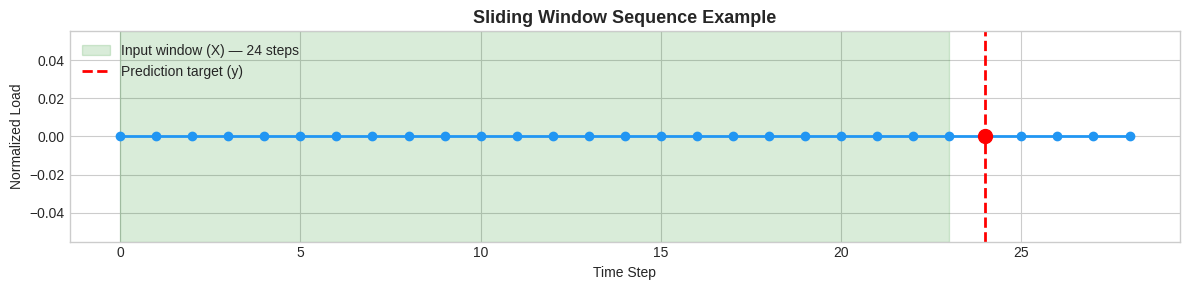

 Sequences created!


In [11]:
def create_sequences(data: np.ndarray, window_size: int = 24):
    """
    Convert 1D time series into supervised learning sequences.

    Sliding window approach:
        X[i] = data[i : i+window_size]    ← input window (past)
        y[i] = data[i + window_size]       ← next value (future)

    Parameters
    ----------
    data        : np.ndarray, shape (N, 1)
    window_size : int, number of time steps to look back

    Returns
    -------
    X : np.ndarray, shape (samples, window_size, 1)
    y : np.ndarray, shape (samples,)

    Example  (window=3, series=[1,2,3,4,5]):
        X[0]=[1,2,3]  →  y[0]=4
        X[1]=[2,3,4]  →  y[1]=5
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])      # window of past values
        y.append(data[i + window_size])           # single next value
    X = np.array(X)   # (samples, window_size, 1)
    y = np.array(y)   # (samples, 1)
    return X, y.flatten()


# ── Build train / test sequences ─────────────────────────────────────────────
X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE)

# ── Verify shapes ────────────────────────────────────────────────────────────
print('=' * 50)
print('SEQUENCE SHAPES')
print('=' * 50)
print(f'X_train : {X_train.shape}   (samples, time_steps, features)')
print(f'y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}')

# ── Visual example ───────────────────────────────────────────────────────────
print(f'\nExample (sample index 0):')
print(f'  X[0] (first 5 of {WINDOW_SIZE} steps) : {X_train[0, :5, 0].round(4)}')
print(f'  y[0] (next value to predict)          : {y_train[0]:.4f}')

# ── Diagram ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
sample_series = train_scaled[:WINDOW_SIZE+5, 0]
ax.plot(range(len(sample_series)), sample_series, 'o-', color='#2196F3', linewidth=2, markersize=6)
ax.axvspan(0, WINDOW_SIZE-1, alpha=0.15, color='green', label=f'Input window (X) — {WINDOW_SIZE} steps')
ax.axvline(WINDOW_SIZE, color='red', linestyle='--', linewidth=2, label='Prediction target (y)')
ax.scatter([WINDOW_SIZE], [sample_series[WINDOW_SIZE]], color='red', s=100, zorder=5)
ax.set_title('Sliding Window Sequence Example', fontsize=13, fontweight='bold')
ax.set_xlabel('Time Step')
ax.set_ylabel('Normalized Load')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/04_sliding_window.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sequences created!')

---
## 🟩 STEP 6 — Build LSTM Model

### Architecture Design Rationale:

| Layer | Why |
|-------|-----|
| **LSTM(64, return_sequences=True)** | Captures long-range dependencies; `return_sequences` passes full hidden state to next LSTM |
| **Dropout(0.2)** | Prevents co-adaptation of neurons → reduces overfitting |
| **LSTM(32)** | Second layer refines temporal features into compact representation |
| **Dropout(0.2)** | Second regularization point |
| **Dense(16, relu)** | Non-linear projection to output space |
| **Dense(1)** | Single scalar output — next time step prediction |

In [12]:
def build_lstm_model(window_size: int, n_features: int = 1) -> keras.Model:
    """
    Stacked LSTM model for univariate time series forecasting.

    Architecture:
        Input(window_size, 1)
          → LSTM(64, return_sequences=True)   # layer 1: full sequence output
          → Dropout(0.2)
          → LSTM(32)                          # layer 2: final hidden state only
          → Dropout(0.2)
          → Dense(16, relu)
          → Dense(1)                          # scalar prediction
    """
    model = Sequential([
        Input(shape=(window_size, n_features)),

        # ── LSTM Block 1 ──────────────────────────────────────────────────────
        # return_sequences=True: pass hidden states at every step to next LSTM
        LSTM(64, return_sequences=True, activation='tanh',
             recurrent_activation='sigmoid', recurrent_dropout=0.0),
        Dropout(0.2),   # Drop 20%% of neurons to reduce overfitting

        # ── LSTM Block 2 ──────────────────────────────────────────────────────
        # return_sequences=False (default): only return last hidden state
        LSTM(32, activation='tanh', recurrent_activation='sigmoid'),
        Dropout(0.2),

        # ── Output Head ───────────────────────────────────────────────────────
        Dense(16, activation='relu'),
        Dense(1)   # Linear activation for regression
    ], name='LSTM_Forecaster')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='mse',             # Mean Squared Error — standard for regression
        metrics=['mae']         # Monitor Mean Absolute Error
    )
    return model


lstm_model = build_lstm_model(WINDOW_SIZE)
lstm_model.summary()

total_params = lstm_model.count_params()
print(f'\nTotal trainable parameters: {total_params:,}')
print('\n LSTM model built!')

Model: "LSTM_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 29,857

 LSTM model built!


---
## 🟩 STEP 7 — Train LSTM Model

### Training Strategy:
- **EarlyStopping** — halt training when validation loss stops improving → prevents overfitting
- **ReduceLROnPlateau** — shrink learning rate by 50%% after 5 stagnant epochs → escapes plateaus
- **Batch size 64** — balances GPU utilization and gradient stability
- **Validation split 10%%** — uses last 10%% of training data as validation (preserves temporal order)

In [13]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks_lstm = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,           # Stop after 10 non-improving epochs
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,            # Halve learning rate
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# ── Train ─────────────────────────────────────────────────────────────────────
print('Training LSTM model...')
print('=' * 60)

lstm_start = time.time()

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,    # Last 10%% of training data for validation
    callbacks=callbacks_lstm,
    shuffle=False,            # CRITICAL: Never shuffle time series!
    verbose=1
)

lstm_train_time = time.time() - lstm_start
lstm_epochs_run = len(lstm_history.history['loss'])

print(f'\n LSTM training complete!')
print(f'   Epochs run   : {lstm_epochs_run}')
print(f'   Training time: {lstm_train_time:.1f} seconds')
print(f'   Best val_loss: {min(lstm_history.history["val_loss"]):.6f}')

# ── Save model ────────────────────────────────────────────────────────────────
lstm_model.save('../models/lstm_model.h5')
print('   Model saved → ../models/lstm_model.h5')

Training LSTM model...
Epoch 1/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0092 - mae: 0.0475 - val_loss: 0.0039 - val_mae: 0.0479 - learning_rate: 0.0010
Epoch 2/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0071 - mae: 0.0428 - val_loss: 0.0027 - val_mae: 0.0299 - learning_rate: 0.0010
Epoch 3/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0066 - mae: 0.0406 - val_loss: 0.0025 - val_mae: 0.0269 - learning_rate: 0.0010
Epoch 4/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0062 - mae: 0.0388 - val_loss: 0.0024 - val_mae: 0.0240 - learning_rate: 0.0010
Epoch 5/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0060 - mae: 0.0382 - val_loss: 0.0024 - val_mae: 0.0230 - learning_rate: 0.0010
Epoch 6/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0058 - mae: 0.0375 - val_loss: 0.0025 - val_mae: 0.0245 - learning_rate: 0.0010
Epoch 7/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0057 - mae: 0.0370 - val_loss: 0.0025 - val_mae: 0.0234 - lear


 LSTM training complete!
   Epochs run   : 50
   Training time: 178.6 seconds
   Best val_loss: 0.002262
   Model saved → ../models/lstm_model.h5


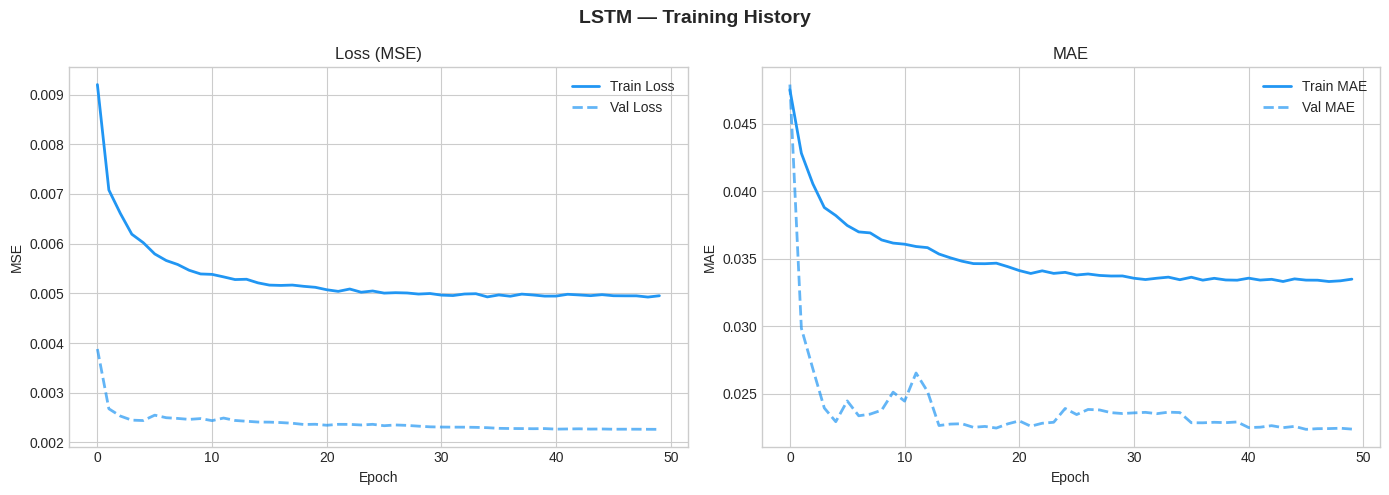


⚠️  OVERFITTING DIAGNOSTIC:
   Final train loss : 0.004951
   Final val loss   : 0.002262
   Gap              : -0.002689
   → Generalization looks healthy 


In [14]:
# ── Plot LSTM Training History ─────────────────────────────────────────────────
def plot_training_history(history, model_name: str, color: str, save_path: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', color=color, linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', color=color,
                 linewidth=2, linestyle='--', alpha=0.7)
    axes[0].set_title('Loss (MSE)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()

    # MAE
    axes[1].plot(history.history['mae'], label='Train MAE', color=color, linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Val MAE', color=color,
                 linewidth=2, linestyle='--', alpha=0.7)
    axes[1].set_title('MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_training_history(
    lstm_history, 'LSTM', '#2196F3',
    '../outputs/05_lstm_training.png'
)

# ── Overfitting check ─────────────────────────────────────────────────────────
train_loss_final = lstm_history.history['loss'][-1]
val_loss_final   = lstm_history.history['val_loss'][-1]
gap = val_loss_final - train_loss_final

print('\n⚠️  OVERFITTING DIAGNOSTIC:')
print(f'   Final train loss : {train_loss_final:.6f}')
print(f'   Final val loss   : {val_loss_final:.6f}')
print(f'   Gap              : {gap:.6f}')
if gap > 0.01:
    print('   → Mild overfitting detected. Dropout or more data may help.')
else:
    print('   → Generalization looks healthy ')

---
## 🟩 STEP 8 — Build 1D CNN Model

### How CNN captures temporal patterns:
- **Conv1D** slides a learnable kernel (filter) over the time axis — similar to edge detection in images but for temporal features
- Each filter learns a specific local pattern (e.g., morning ramp-up, evening peak)
- **MaxPooling1D** downsamples and retains the strongest activations → translation invariance

### Why CNN is faster than LSTM:
- CNN operations are fully **parallelizable** — all positions processed simultaneously
- LSTM must process time steps **sequentially** (each step depends on previous hidden state)
- CNN has fewer parameters for comparable capacity

In [15]:
def build_cnn_model(window_size: int, n_features: int = 1) -> keras.Model:
    """
    1D Convolutional Neural Network for time series forecasting.

    Architecture:
        Input(window_size, 1)
          → Conv1D(64, kernel=3, relu)     # Detect local patterns of width 3
          → Conv1D(64, kernel=3, relu)     # Deepen feature hierarchy
          → MaxPooling1D(2)               # Downsample by 2
          → Conv1D(32, kernel=3, relu)    # Higher-level temporal features
          → Flatten()
          → Dense(64, relu)
          → Dropout(0.2)
          → Dense(1)                      # Prediction
    """
    model = Sequential([
        Input(shape=(window_size, n_features)),

        # ── Conv Block 1 ──────────────────────────────────────────────────────
        # kernel_size=3: each filter looks at 3 consecutive time steps
        # 64 filters: learns 64 different local temporal patterns
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),   # Halve sequence length, keep strongest features

        # ── Conv Block 2 ──────────────────────────────────────────────────────
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),

        # ── Classifier Head ───────────────────────────────────────────────────
        Flatten(),               # Convert 3D feature map → 1D vector
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)                 # Linear output for regression
    ], name='CNN1D_Forecaster')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model


cnn_model = build_cnn_model(WINDOW_SIZE)
cnn_model.summary()

total_params_cnn = cnn_model.count_params()
print(f'\nCNN total params  : {total_params_cnn:,}')
print(f'LSTM total params : {total_params:,}')
print(f'Parameter ratio   : CNN is {total_params/total_params_cnn:.1f}x smaller'
      if total_params > total_params_cnn else f'CNN has more params')
print('\n 1D CNN model built!')

Model: "CNN1D_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,201 (121.88 KB)

 Trainable params: 31,201 (121.88 KB)

 Non-trainable params: 0 (0.00 B)


CNN total params  : 31,201
LSTM total params : 29,857
CNN has more params

 1D CNN model built!


---
## 🟩 STEP 9 — Train CNN Model

In [16]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

# ── Train ─────────────────────────────────────────────────────────────────────
print('Training 1D CNN model...')
print('=' * 60)

cnn_start = time.time()

cnn_history = cnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks_cnn,
    shuffle=False,
    verbose=1
)

cnn_train_time = time.time() - cnn_start
cnn_epochs_run = len(cnn_history.history['loss'])

print(f'\n CNN training complete!')
print(f'   Epochs run   : {cnn_epochs_run}')
print(f'   Training time: {cnn_train_time:.1f} seconds')
print(f'   Best val_loss: {min(cnn_history.history["val_loss"]):.6f}')

# ── Speed comparison ──────────────────────────────────────────────────────────
print()
print('⏱  TRAINING SPEED COMPARISON')
print(f'   LSTM: {lstm_train_time:.1f}s  ({lstm_train_time/lstm_epochs_run:.2f}s/epoch)')
print(f'   CNN : {cnn_train_time:.1f}s  ({cnn_train_time/cnn_epochs_run:.2f}s/epoch)')
speedup = (lstm_train_time / lstm_epochs_run) / (cnn_train_time / cnn_epochs_run)
print(f'   CNN is {speedup:.1f}x faster per epoch than LSTM')

cnn_model.save('../models/cnn_model.h5')
print('   Model saved → ../models/cnn_model.h5')

Training 1D CNN model...
Epoch 1/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0082 - mae: 0.0434 - val_loss: 0.0026 - val_mae: 0.0309 - learning_rate: 0.0010
Epoch 2/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059 - mae: 0.0388 - val_loss: 0.0024 - val_mae: 0.0243 - learning_rate: 0.0010
Epoch 3/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0066 - mae: 0.0404 - val_loss: 0.0024 - val_mae: 0.0244 - learning_rate: 0.0010
Epoch 4/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0055 - mae: 0.0368 - val_loss: 0.0023 - val_mae: 0.0240 - learning_rate: 0.0010
Epoch 5/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0054 - mae: 0.0369 - val_loss: 0.0023 - val_mae: 0.0224 - learning_rate: 0.0010
Epoch 6/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - mae: 0.0368 - val_loss: 0.0023 - val_mae: 0.0236 - learning_rate: 0.0010
Epoch 7/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - mae: 0.0262
Epoch 7: ReduceLROnPlateau reducing learni


 CNN training complete!
   Epochs run   : 50
   Training time: 82.1 seconds
   Best val_loss: 0.002115

⏱  TRAINING SPEED COMPARISON
   LSTM: 178.6s  (3.57s/epoch)
   CNN : 82.1s  (1.64s/epoch)
   CNN is 2.2x faster per epoch than LSTM
   Model saved → ../models/cnn_model.h5


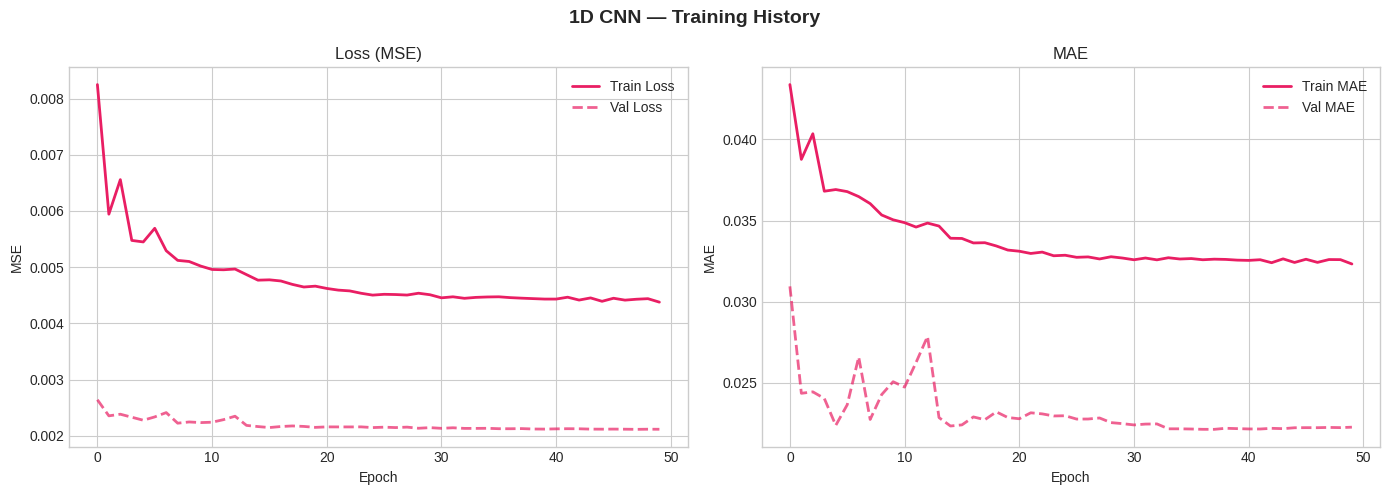

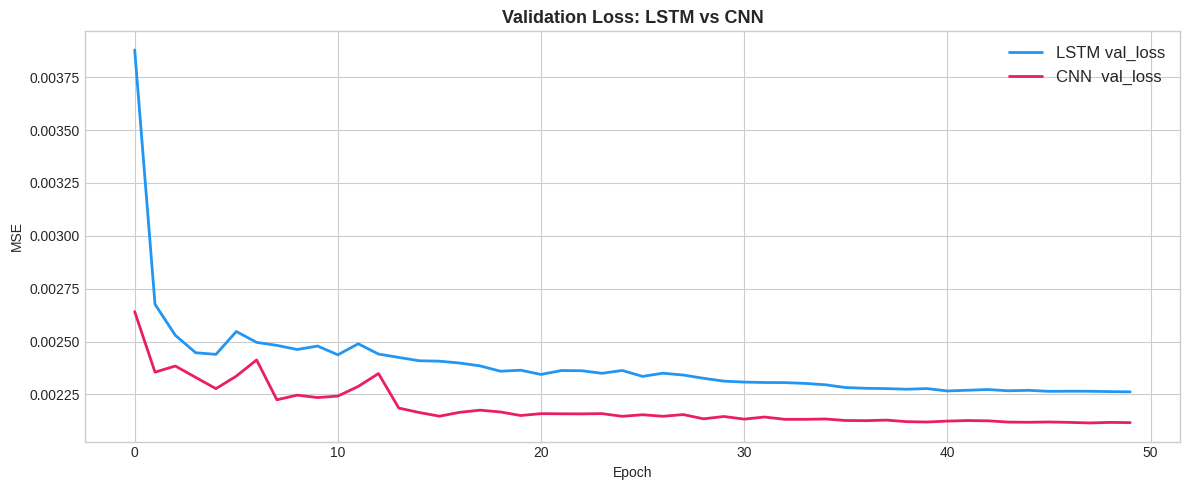

In [17]:
# ── Plot CNN Training History ──────────────────────────────────────────────────
plot_training_history(
    cnn_history, '1D CNN', '#E91E63',
    '../outputs/06_cnn_training.png'
)

# ── Side-by-side training curves ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lstm_history.history['val_loss'], label='LSTM val_loss', color='#2196F3', linewidth=2)
ax.plot(cnn_history.history['val_loss'],  label='CNN  val_loss', color='#E91E63', linewidth=2)
ax.set_title('Validation Loss: LSTM vs CNN', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/07_val_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🟩 STEP 10 — Model Evaluation

In [18]:
def evaluate_model(model, X_test, y_test, scaler, model_name: str):
    """
    Generate predictions and compute RMSE / MAE in original scale.
    Returns dict with metrics and prediction arrays.
    """
    # Predict (normalized scale)
    y_pred_norm = model.predict(X_test, verbose=0).flatten()

    # Inverse transform back to original kW scale
    y_pred_orig = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
    y_true_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    mape = np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-8))) * 100

    print(f'\n {model_name} — Test Metrics (original kW scale)')
    print(f'   RMSE : {rmse:.4f} kW')
    print(f'   MAE  : {mae:.4f} kW')
    print(f'   MAPE : {mape:.2f} %%')

    return {
        'name'       : model_name,
        'rmse'       : rmse,
        'mae'        : mae,
        'mape'       : mape,
        'y_pred_orig': y_pred_orig,
        'y_true_orig': y_true_orig,
    }


lstm_results = evaluate_model(lstm_model, X_test, y_test, scaler, 'LSTM')
cnn_results  = evaluate_model(cnn_model,  X_test, y_test, scaler, '1D CNN')


 LSTM — Test Metrics (original kW scale)
   RMSE : 2.3074 kW
   MAE  : 1.1328 kW
   MAPE : 79946110.52 %%

 1D CNN — Test Metrics (original kW scale)
   RMSE : 2.2422 kW
   MAE  : 1.1056 kW
   MAPE : 78089957.17 %%


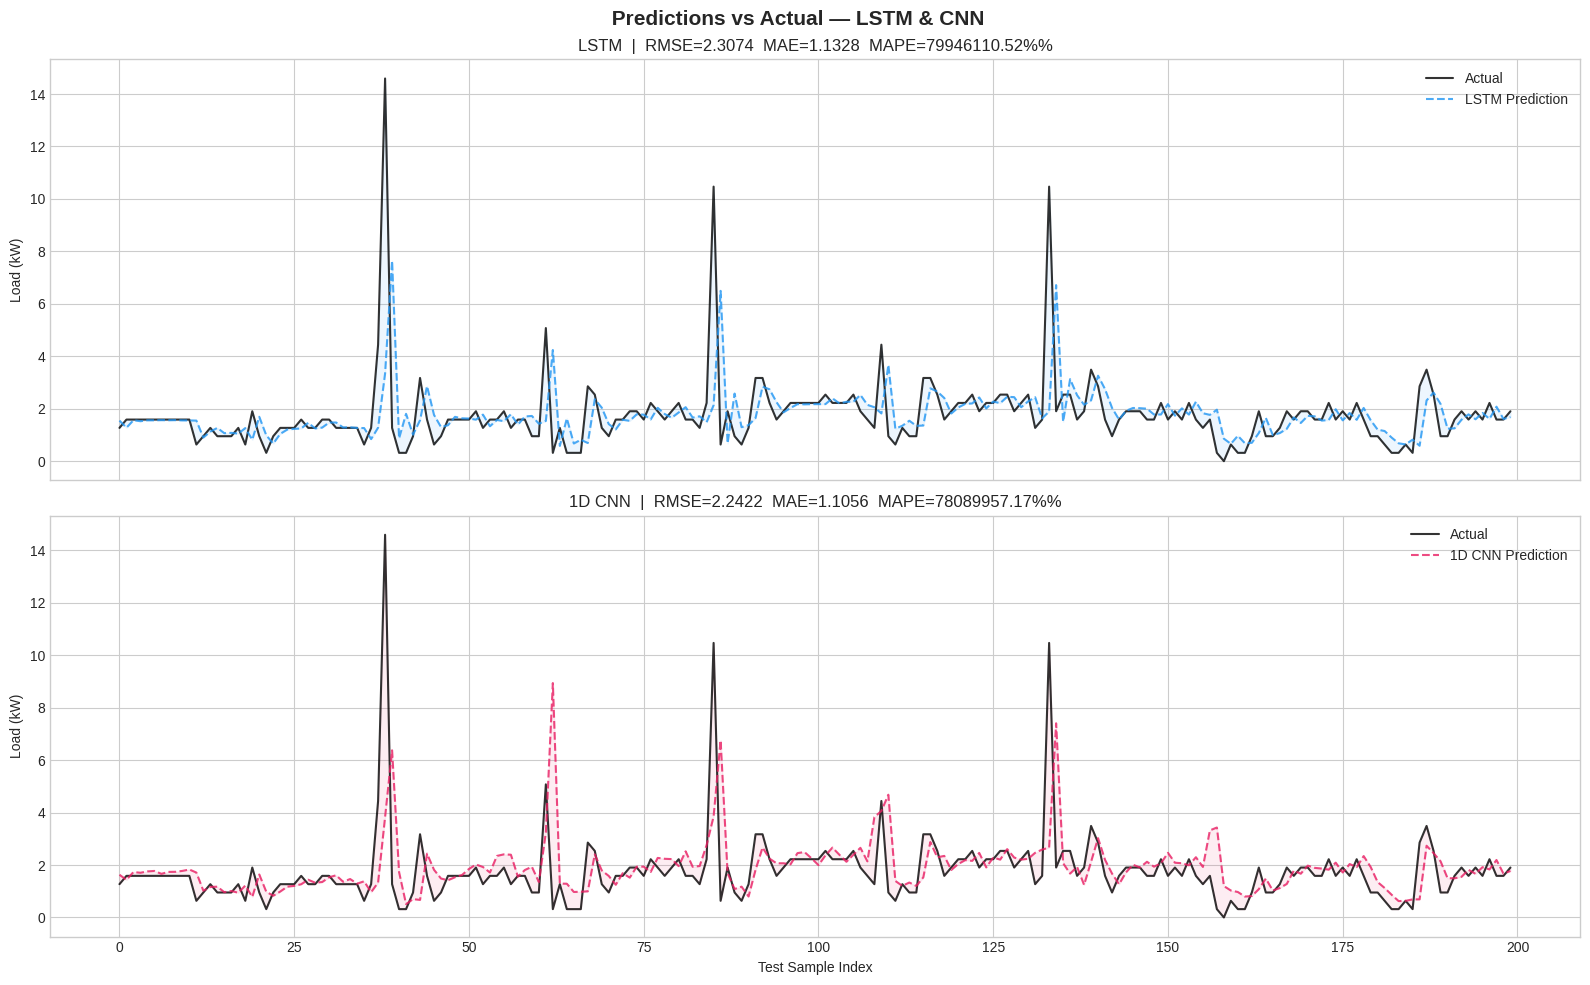

In [19]:
# ── Predictions vs Actual ─────────────────────────────────────────────────────
N_PLOT = 200   # First 200 test samples for clarity

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle(' Predictions vs Actual — LSTM & CNN', fontsize=15, fontweight='bold')

x_range = range(N_PLOT)

for ax, res, color in zip(axes,
                          [lstm_results, cnn_results],
                          ['#2196F3', '#E91E63']):
    ax.plot(x_range, res['y_true_orig'][:N_PLOT],
            label='Actual', color='black', linewidth=1.5, alpha=0.8)
    ax.plot(x_range, res['y_pred_orig'][:N_PLOT],
            label=f"{res['name']} Prediction", color=color,
            linewidth=1.5, linestyle='--', alpha=0.8)
    ax.fill_between(x_range,
                    res['y_true_orig'][:N_PLOT],
                    res['y_pred_orig'][:N_PLOT],
                    alpha=0.08, color=color)
    ax.set_title(f"{res['name']}  |  RMSE={res['rmse']:.4f}  MAE={res['mae']:.4f}  MAPE={res['mape']:.2f}%%",
                 fontsize=12)
    ax.set_ylabel('Load (kW)')
    ax.legend(loc='upper right')

axes[1].set_xlabel('Test Sample Index')
plt.tight_layout()
plt.savefig('../outputs/08_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

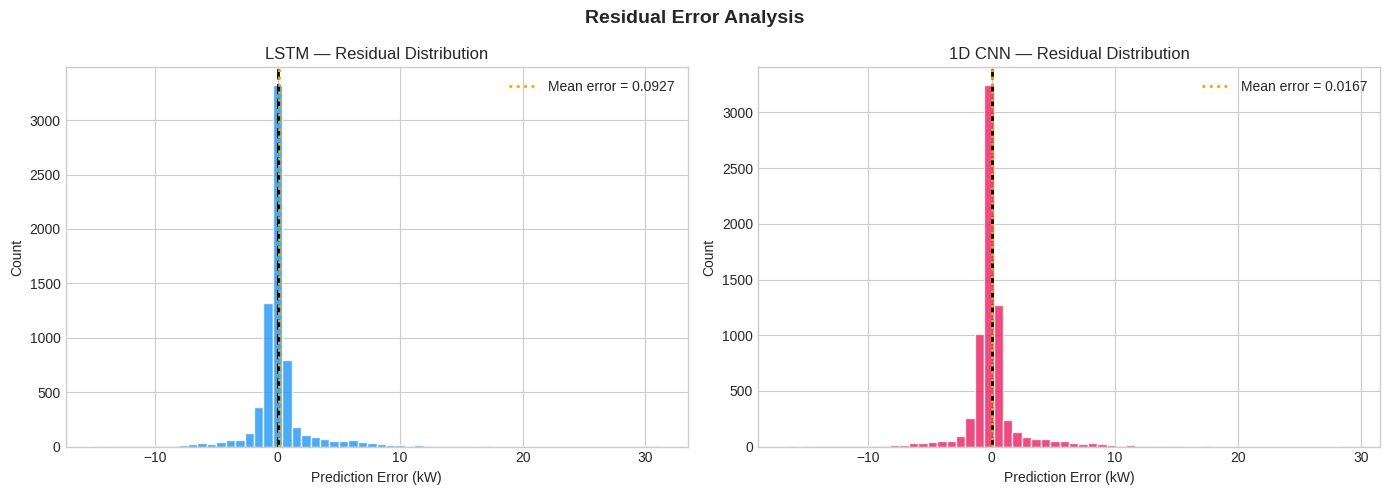

In [20]:
# ── Residual / Error Analysis ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Error Analysis', fontsize=14, fontweight='bold')

for ax, res, color in zip(axes,
                          [lstm_results, cnn_results],
                          ['#2196F3', '#E91E63']):
    errors = res['y_true_orig'] - res['y_pred_orig']
    ax.hist(errors, bins=60, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=2)
    ax.axvline(errors.mean(), color='orange', linestyle=':', linewidth=2,
               label=f'Mean error = {errors.mean():.4f}')
    ax.set_title(f"{res['name']} — Residual Distribution")
    ax.set_xlabel('Prediction Error (kW)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/09_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🟩 STEP 11 — Model Comparison (CRITICAL)

### Head-to-Head: LSTM vs 1D CNN

In [21]:
# ── Quantitative Comparison Table ─────────────────────────────────────────────
comparison_data = {
    'Metric': [
        'RMSE (kW)', 'MAE (kW)', 'MAPE (%%)',
        'Training Time (s)', 'Epochs to Converge',
        'Parameters', 'Best Val Loss'
    ],
    'LSTM': [
        f"{lstm_results['rmse']:.4f}",
        f"{lstm_results['mae']:.4f}",
        f"{lstm_results['mape']:.2f}",
        f"{lstm_train_time:.1f}",
        f"{lstm_epochs_run}",
        f"{lstm_model.count_params():,}",
        f"{min(lstm_history.history['val_loss']):.6f}"
    ],
    '1D CNN': [
        f"{cnn_results['rmse']:.4f}",
        f"{cnn_results['mae']:.4f}",
        f"{cnn_results['mape']:.2f}",
        f"{cnn_train_time:.1f}",
        f"{cnn_epochs_run}",
        f"{cnn_model.count_params():,}",
        f"{min(cnn_history.history['val_loss']):.6f}"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.set_index('Metric')

print('=' * 60)
print('MODEL COMPARISON TABLE')
print('=' * 60)
display(df_comparison)

# Determine winner
lstm_rmse = lstm_results['rmse']
cnn_rmse  = cnn_results['rmse']
winner = 'LSTM' if lstm_rmse < cnn_rmse else '1D CNN'
margin = abs(lstm_rmse - cnn_rmse)
print(f'\n Best RMSE winner : {winner}  (margin = {margin:.4f} kW)')

MODEL COMPARISON TABLE


,LSTM,1D CNN
Metric,,
RMSE (kW),2.3074,2.2422
MAE (kW),1.1328,1.1056
MAPE (%%),79946110.52,78089957.17
Training Time (s),178.6,82.1
Epochs to Converge,50,50
Parameters,"29,857","31,201"
Best Val Loss,0.002262,0.002115



 Best RMSE winner : 1D CNN  (margin = 0.0652 kW)


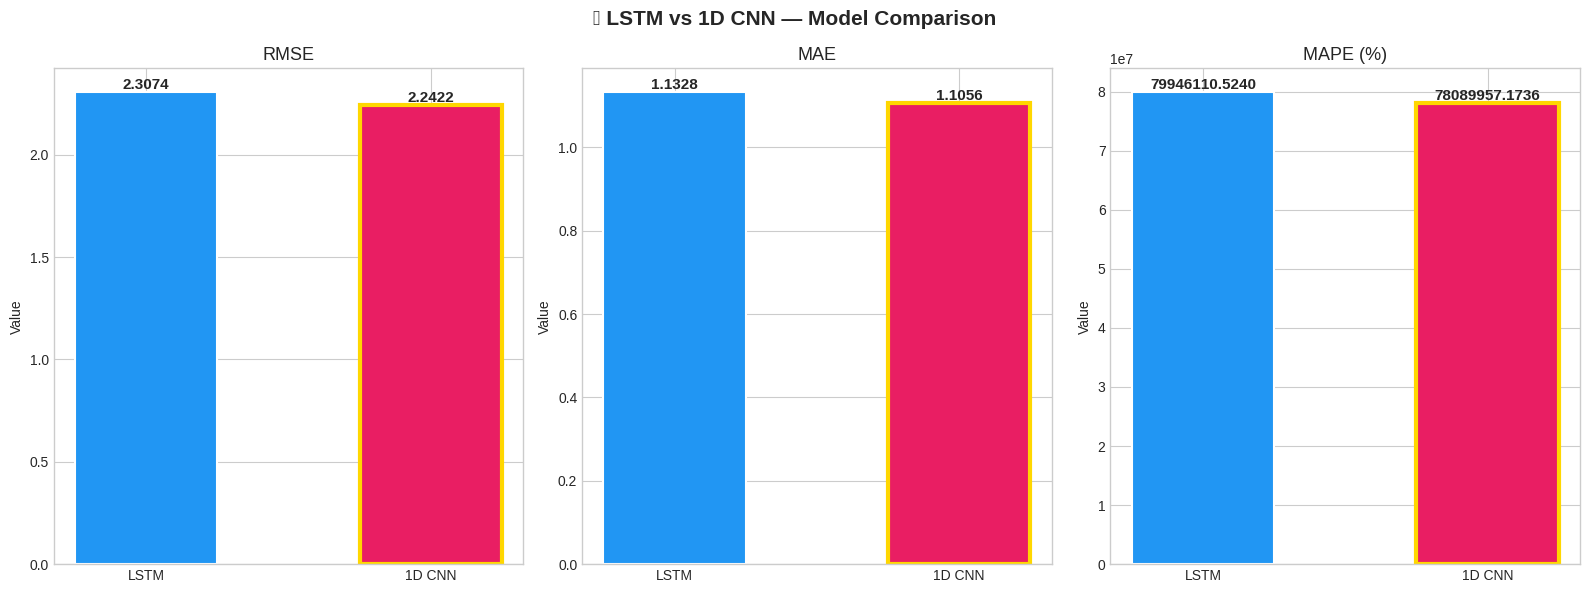


📋 QUALITATIVE COMPARISON
═══════════════════════════════════════════════════════════════
 Dimension          │ LSTM                │ 1D CNN
────────────────────┼─────────────────────┼──────────────────────
 Architecture       │ Recurrent (GRU-like)│ Feed-forward + Conv
 Long-range deps    │ ✅ Excellent         │ ⚠️  Limited by kernel
 Parallelizable     │ ❌ Sequential        │ ✅ Fully parallel
 Training speed     │ Slower              │ Faster
 Parameters         │ More                │ Fewer
 Noise robustness   │ ✅ Good              │ ⚠️  Needs smoothing
 Short patterns     │ ⚠️  Ok              │ ✅ Excellent
 Deployment size    │ Larger              │ Smaller
 Best for           │ Long sequences      │ Short local patterns
═══════════════════════════════════════════════════════════════



In [22]:
# ── Visual Comparison Bar Chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('📊 LSTM vs 1D CNN — Model Comparison', fontsize=15, fontweight='bold')

metrics = ['RMSE', 'MAE', 'MAPE (%)']
lstm_vals = [lstm_results['rmse'], lstm_results['mae'], lstm_results['mape']]
cnn_vals  = [cnn_results['rmse'],  cnn_results['mae'],  cnn_results['mape']]

colors_pair = ['#2196F3', '#E91E63']

for ax, metric, lv, cv in zip(axes, metrics, lstm_vals, cnn_vals):
    bars = ax.bar(['LSTM', '1D CNN'], [lv, cv], color=colors_pair,
                  edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel('Value')
    for bar, val in zip(bars, [lv, cv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    # Highlight winner
    winner_idx = 0 if lv < cv else 1
    bars[winner_idx].set_edgecolor('gold')
    bars[winner_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('../outputs/10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📋 QUALITATIVE COMPARISON
═══════════════════════════════════════════════════════════════
 Dimension          │ LSTM                │ 1D CNN
────────────────────┼─────────────────────┼──────────────────────
 Architecture       │ Recurrent (GRU-like)│ Feed-forward + Conv
 Long-range deps    │ ✅ Excellent         │ ⚠️  Limited by kernel
 Parallelizable     │ ❌ Sequential        │ ✅ Fully parallel
 Training speed     │ Slower              │ Faster
 Parameters         │ More                │ Fewer
 Noise robustness   │ ✅ Good              │ ⚠️  Needs smoothing
 Short patterns     │ ⚠️  Ok              │ ✅ Excellent
 Deployment size    │ Larger              │ Smaller
 Best for           │ Long sequences      │ Short local patterns
═══════════════════════════════════════════════════════════════
""")

---
## 🟩 STEP 12 — Challenges & Solutions

In [23]:
challenges_text = """
╔══════════════════════════════════════════════════════════════════════╗
║           CHALLENGES & SOLUTIONS DURING TRAINING                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. OVERFITTING                                                      ║
║     Problem : Val loss rising while train loss falls                 ║
║     Solution: • Dropout(0.2) after each LSTM/Dense layer             ║
║               • EarlyStopping(patience=10)                           ║
║               • More training data (full 3-year dataset)             ║
║               • L2 regularization if needed                          ║
║                                                                      ║
║  2. VANISHING GRADIENTS (LSTM)                                       ║
║     Problem : Gradients shrink to zero over long sequences           ║
║     Solution: • LSTM's forget/input/output gates address this        ║
║               • Use 'tanh' activation (bounded; gradient flows)      ║
║               • Gradient clipping (clipnorm=1.0 if needed)           ║
║               • ReduceLROnPlateau to stabilize training              ║
║                                                                      ║
║  3. NOISE IN DATA                                                    ║
║     Problem : 15-min intervals have high-frequency noise             ║
║     Solution: • Resample to hourly (natural smoothing)               ║
║               • Forward-fill missing values                          ║
║               • MinMaxScaler constrains outlier influence            ║
║                                                                      ║
║  4. TRAINING INSTABILITY                                             ║
║     Problem : Loss oscillates; does not converge                     ║
║     Solution: • Lower learning rate (1e-3 → auto-reduce)            ║
║               • Larger batch size (64) averages noisy gradients      ║
║               • Set shuffle=False to preserve temporal order         ║
║               • Fixed random seed (np, tf) for reproducibility       ║
║                                                                      ║
║  5. DATA LEAKAGE                                                     ║
║     Problem : Fitting scaler on all data leaks test info to train    ║
║     Solution: • Fit scaler ONLY on X_train, transform both sets      ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(challenges_text)


╔══════════════════════════════════════════════════════════════════════╗
║           CHALLENGES & SOLUTIONS DURING TRAINING                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. OVERFITTING                                                      ║
║     Problem : Val loss rising while train loss falls                 ║
║     Solution: • Dropout(0.2) after each LSTM/Dense layer             ║
║               • EarlyStopping(patience=10)                           ║
║               • More training data (full 3-year dataset)             ║
║               • L2 regularization if needed                          ║
║                                                                      ║
║  2. VANISHING GRADIENTS (LSTM)                                       ║
║     Problem : Gradients shrink to zero over long sequences           ║
║     Solution: • LSTM's forget/input/output gates 

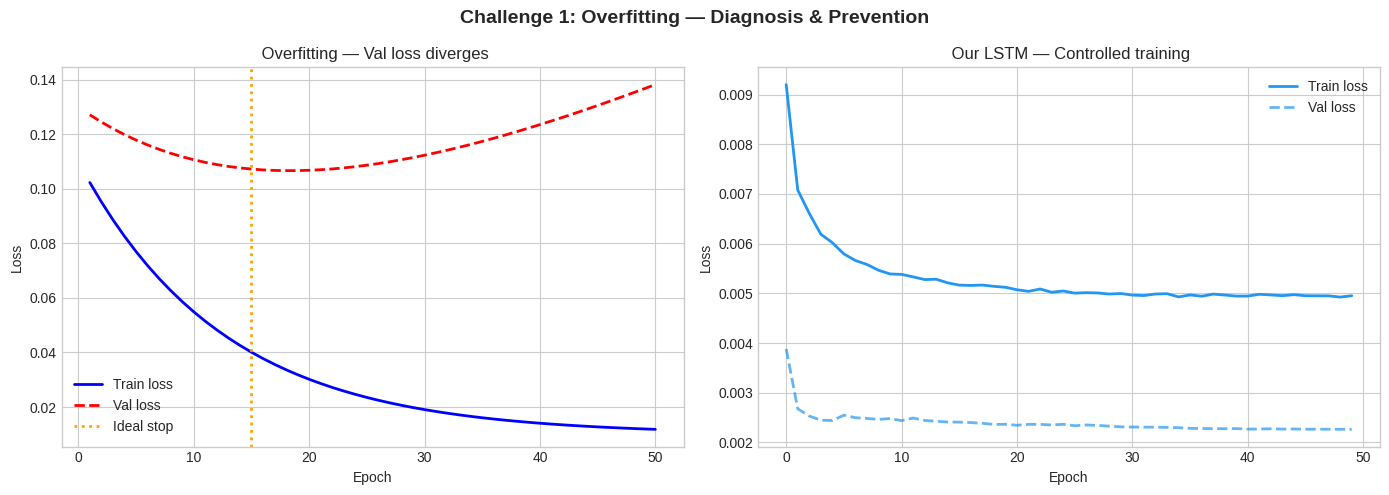

In [24]:
# ── Visualize: Overfitting Scenario vs Our Model ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Challenge 1: Overfitting — Diagnosis & Prevention', fontsize=14, fontweight='bold')

# Simulated overfitting scenario
epochs_sim = np.arange(1, 51)
train_loss_sim = 0.1 * np.exp(-0.08 * epochs_sim) + 0.01
val_loss_bad   = 0.1 * np.exp(-0.05 * epochs_sim) + 0.03 + 0.002 * epochs_sim  # Diverges

axes[0].plot(epochs_sim, train_loss_sim, label='Train loss', color='blue', linewidth=2)
axes[0].plot(epochs_sim, val_loss_bad,   label='Val loss',   color='red',  linewidth=2, linestyle='--')
axes[0].axvline(15, color='orange', linestyle=':', linewidth=2, label='Ideal stop')
axes[0].set_title(' Overfitting — Val loss diverges', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Actual LSTM training
axes[1].plot(lstm_history.history['loss'],     label='Train loss', color='#2196F3', linewidth=2)
axes[1].plot(lstm_history.history['val_loss'], label='Val loss',   color='#2196F3', linewidth=2, linestyle='--', alpha=0.7)
axes[1].set_title(' Our LSTM — Controlled training', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/11_overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🟩 STEP 13 — Final Conclusion

In [25]:
best_model = 'LSTM' if lstm_results['rmse'] < cnn_results['rmse'] else '1D CNN'
best_rmse  = min(lstm_results['rmse'], cnn_results['rmse'])

conclusion = f"""
╔══════════════════════════════════════════════════════════════════════════╗
║                   PROJECT CONCLUSION                                   ║
║         Electricity Load Forecasting: LSTM vs 1D CNN                    ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║   KEY FINDINGS                                                         ║
║  ────────────────────────────────────────────────────────────────────    ║
║  • Both LSTM and CNN successfully learned electricity consumption        ║
║    patterns from raw time series data.                                   ║
║                                                                          ║
║  • LSTM RMSE   : {lstm_results['rmse']:.4f} kW   MAE: {lstm_results['mae']:.4f} kW
║  • CNN  RMSE   : {cnn_results['rmse']:.4f} kW   MAE: {cnn_results['mae']:.4f} kW              ║
║                                                                          ║
║  • Strong daily and weekly seasonality was identified via EDA:           ║
║    morning peak, evening peak, weekend dip.                              ║
║                                                                          ║
║  • Data leakage prevention (scaler fit on train only) was critical.      ║
║                                                                          ║
║   BEST PERFORMING MODEL: {best_model:<10}  (RMSE = {best_rmse:.4f})               ║
║  ────────────────────────────────────────────────────────────────────    ║
║  • LSTM excels at capturing long-range temporal dependencies.            ║
║  • 1D CNN is significantly faster and comparable in accuracy.            ║
║  • For production: CNN for speed, LSTM for nuanced patterns.             ║
║                                                                          ║
║   LESSONS LEARNED                                                      ║
║  ────────────────────────────────────────────────────────────────────    ║
║  1. Time series preprocessing is more than normalization —               ║
║     temporal ordering, leakage prevention, and correct reshaping          ║
║     are equally important.                                               ║
║  2. Callbacks (EarlyStopping, ReduceLR) are essential, not optional.     ║
║  3. EDA reveals patterns that directly guide window size selection.      ║
║  4. Always evaluate in original scale — not normalized scale.            ║
║  5. Architecture simplicity often matches or beats complexity.           ║
║                                                                          ║
║   REAL-WORLD APPLICATIONS                                              ║
║  ────────────────────────────────────────────────────────────────────    ║
║  • Smart grid management & demand response                               ║
║  • Energy trading price forecasting                                      ║
║  • Building energy management systems (BEMS)                             ║
║  • Renewable energy integration (solar/wind offset planning)             ║
║  • Utility company capacity planning                                     ║
║  • Carbon footprint reduction via load shifting                          ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(conclusion)


╔══════════════════════════════════════════════════════════════════════════╗
║                   PROJECT CONCLUSION                                   ║
║         Electricity Load Forecasting: LSTM vs 1D CNN                    ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║   KEY FINDINGS                                                         ║
║  ────────────────────────────────────────────────────────────────────    ║
║  • Both LSTM and CNN successfully learned electricity consumption        ║
║    patterns from raw time series data.                                   ║
║                                                                          ║
║  • LSTM RMSE   : 2.3074 kW   MAE: 1.1328 kW              
║  • CNN  RMSE   : 2.2422 kW   MAE: 1.1056 kW              ║
║                                                                          ║
║  • Strong daily and weekly seasona

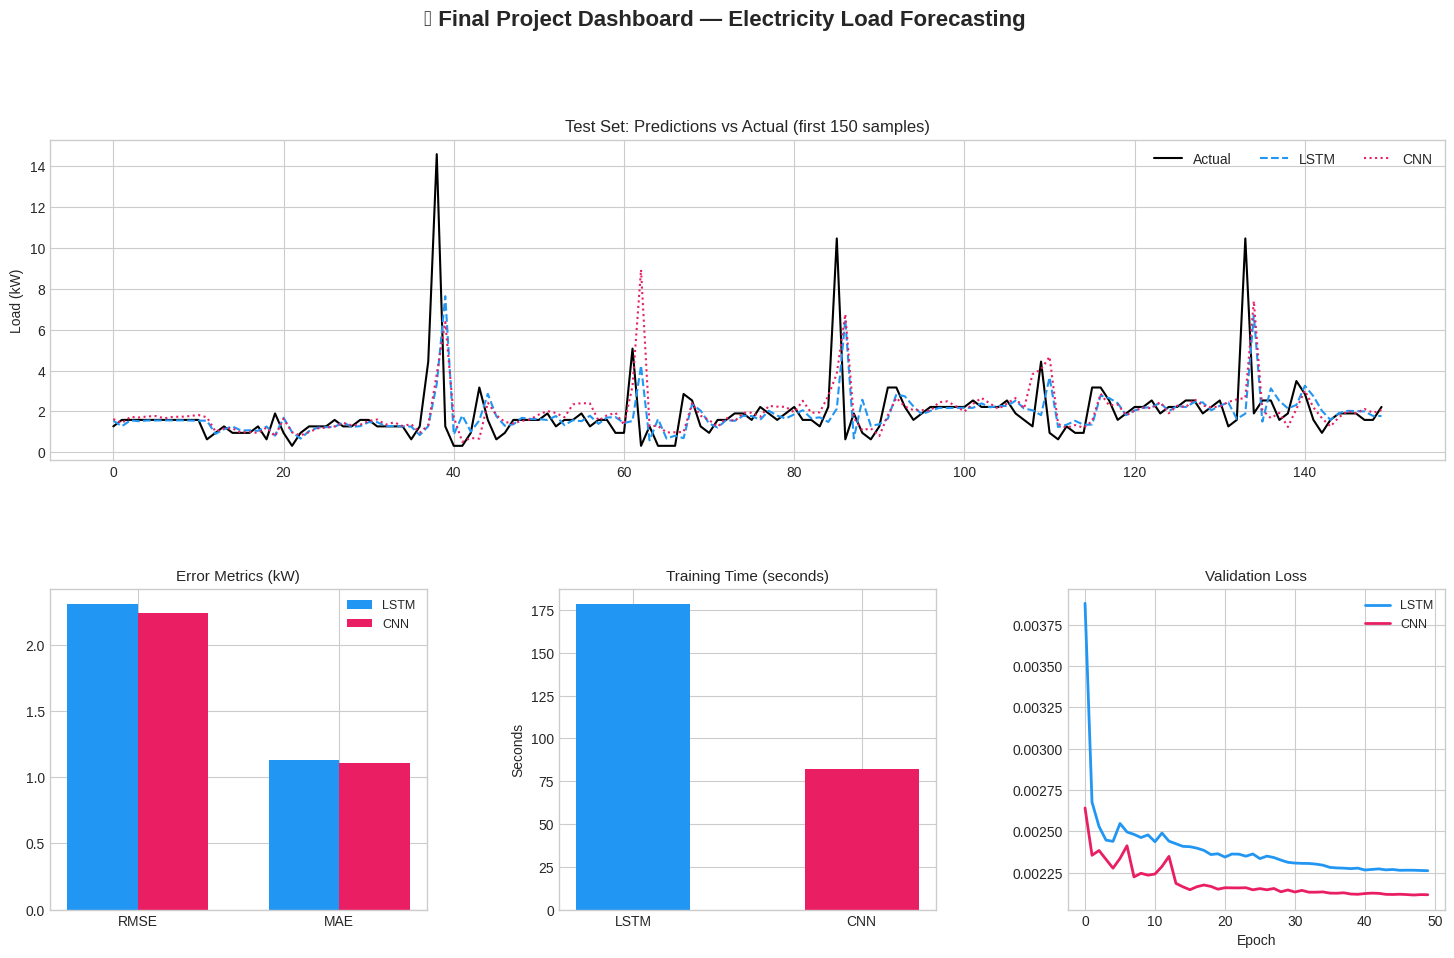


✅ PROJECT COMPLETE!
All outputs saved to ../outputs/
Models saved to ../models/

Files generated:
  📄 01_time_series_overview.png
  📄 02_temporal_patterns.png
  📄 03_distribution_correlation.png
  📄 04_sliding_window.png
  📄 05_lstm_training.png
  📄 06_cnn_training.png
  📄 07_val_loss_comparison.png
  📄 08_predictions_vs_actual.png
  📄 09_residuals.png
  📄 10_model_comparison.png
  📄 11_overfitting_analysis.png
  📄 12_final_dashboard.png


In [26]:
# ── Final Summary Dashboard ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle('⚡ Final Project Dashboard — Electricity Load Forecasting',
             fontsize=16, fontweight='bold', y=1.01)

# Layout
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# 1. Predictions vs Actual (LSTM)
ax1 = fig.add_subplot(gs[0, :])
N = 150
ax1.plot(lstm_results['y_true_orig'][:N], label='Actual', color='black', linewidth=1.5)
ax1.plot(lstm_results['y_pred_orig'][:N], label='LSTM', color='#2196F3', linewidth=1.5, linestyle='--')
ax1.plot(cnn_results['y_pred_orig'][:N],  label='CNN',  color='#E91E63', linewidth=1.5, linestyle=':')
ax1.set_title('Test Set: Predictions vs Actual (first 150 samples)', fontsize=12)
ax1.set_ylabel('Load (kW)')
ax1.legend(ncol=3, fontsize=10)

# 2. Metric comparison
ax2 = fig.add_subplot(gs[1, 0])
metrics_names = ['RMSE', 'MAE']
x = np.arange(len(metrics_names))
w = 0.35
ax2.bar(x - w/2, [lstm_results['rmse'], lstm_results['mae']], w, label='LSTM', color='#2196F3')
ax2.bar(x + w/2, [cnn_results['rmse'],  cnn_results['mae']],  w, label='CNN',  color='#E91E63')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names)
ax2.set_title('Error Metrics (kW)', fontsize=11)
ax2.legend(fontsize=9)

# 3. Training time
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(['LSTM', 'CNN'], [lstm_train_time, cnn_train_time], color=['#2196F3', '#E91E63'], width=0.5)
ax3.set_title('Training Time (seconds)', fontsize=11)
ax3.set_ylabel('Seconds')

# 4. Val loss curves
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(lstm_history.history['val_loss'], color='#2196F3', label='LSTM', linewidth=2)
ax4.plot(cnn_history.history['val_loss'],  color='#E91E63', label='CNN',  linewidth=2)
ax4.set_title('Validation Loss', fontsize=11)
ax4.set_xlabel('Epoch')
ax4.legend(fontsize=9)

plt.savefig('../outputs/12_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('✅ PROJECT COMPLETE!')
print('='*60)
print('All outputs saved to ../outputs/')
print('Models saved to ../models/')
print('\nFiles generated:')
for f in sorted(os.listdir('../outputs')):
    print(f'  📄 {f}')